(30000, 6912)
  Data allocation time: 0.00 s
  Matrix memory usage:  395.5 MB

Method: FFT-based LoG CWT (RAM-heavy)
  Using workers=4 for FFTs
[[ -9315828.       -0.j  -10464133.-71861630.j   -6939858.+15198306.j
  ...  16071854.+28863788.j   -6939858.-15198306.j
  -10464133.+71861630.j ]
 [ 17425596.+29585648.j  -89026400. +1264470.j    2099547. +2902306.j
  ...  23927774.-19206144.j  -15510980.-14305510.j
   78585610. -3301153.8j]
 [ 41622384. -6740286.j   -5772385.+75401890.j   13718532. -3660044.j
  ... -20742846.-22915596.j   -9346090.+15896023.j
    9308754.-80007200.j ]
 ...
 [-12543828.+44796150.j  -86525890. +8871965.j   18382080.-17634478.j
  ...  26551196.-18243630.j    2576760. +3921190.j
   66923540.-14280948.j ]
 [ 41622384. +6740286.j    9308754.+80007200.j   -9346090.-15896023.j
  ... -11624970.-27852078.j   13718532. +3660044.j
   -5772385.-75401890.j ]
 [ 17425596.-29585648.j   78585610. +3301153.8j -15510980.+14305510.j
  ... -25394804.+18796588.j    2099547. -29023

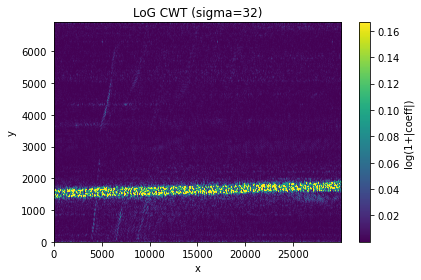

Step/scale times (seconds):
      fft2_forward:     2.92
        scale_32.0:    10.61
Total CWT time (incl FFT): 23.83 s


In [ ]:
import os
import gc
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
# Optional FFT path (commented unless you enable it below)
from scipy.fft import fft2, ifft2, fftfreq


import argparse
import sys
from typing import Union
import numpy as np


def make_data(h=30000, w=5000, dtype=np.float32, seed=0):
    rng = np.random.default_rng(seed)
    # Generator supports dtype; this halves RAM vs float64
    X = rng.standard_normal((h, w), dtype=dtype)
    return X

def cwt2_log_ndimage(X, sigmas, out_stats=False):
    """
    LoG-based 2D CWT via ndimage (separable filters; low RAM).
    sigmas: iterable of scales (in pixels). Larger = coarser.
    Returns per-scale timings and optional simple stats.
    """
    timings = []
    stats = []

    for s in sigmas:
        t0 = time.perf_counter()
        # gaussian_laplace computes ∇^2(G_sigma * X), i.e., LoG at scale sigma.
        # Up to constant/sign, this is the Mexican-hat CWT response.
        coeff = ndimage.gaussian_laplace(X, sigma=float(s), mode='reflect')
        dt = time.perf_counter() - t0
        timings.append((s, dt))

        if out_stats:
            # Keep tiny stats only (don’t keep coeff to save RAM)
            stats.append((s, float(np.mean(coeff)), float(np.std(coeff))))
        del coeff
        gc.collect()

    return timings, stats if out_stats else None

def cwt2_log_fft(X, sigmas, workers=4, keep_last=False):
    """
    OPTIONAL: LoG-based 2D CWT via FFT convolution (fast but RAM-hungry).
    For a 30000x5000 array, expect multiple GB of peak usage.
    """
    H, W = X.shape
    # Complex64 keeps memory lower than float64-complex
    Xc = X.astype(np.float32, copy=False)
    t0 = time.perf_counter()
    F = fft2(Xc, workers=workers)  # -> complex64 if input is float32
    print(F)
    t_fft = time.perf_counter() - t0

    # Build frequency grids as 1D (small) and use broadcasting
    ky = (2 * np.pi) * fftfreq(H, d=1.0).astype(np.float32)  # shape (H,)
    kx = (2 * np.pi) * fftfreq(W, d=1.0).astype(np.float32)  # shape (W,)
    ky2 = ky * ky                                           # (H,)
    kx2 = kx * kx                                           # (W,)


    timings = [("fft2_forward", t_fft)]
    last_coeff = None

    for s in sigmas:
        s = float(s)
        t1 = time.perf_counter()
        # |k|^2 * exp(-0.5*(s^2)*|k|^2)  (LoG in frequency domain; constants ignored)
        # This broadcasts to (H, W) without extra large temporaries beyond the product itself.
        k2 = ky2[:, None] + kx2[None, :]
        
        print(k2.shape)
        psi_hat = k2 * np.exp(-0.5 * (s * s) * k2, dtype=np.float32)  # float32
        Ff = F * psi_hat                                              # complex64
        coeff = ifft2(Ff, workers=workers).real.astype(np.float32, copy=False)
        dt = time.perf_counter() - t1
        timings.append((f"scale_{s}", dt))

        if keep_last:
            last_coeff = coeff
        else:
            del coeff
        del psi_hat, Ff
        gc.collect()

    return timings, last_coeff

def bytes_human(n):
    for unit in ["B","KB","MB","GB","TB"]:
        if n < 1024: return f"{n:.1f} {unit}"
        n /= 1024.0
    return f"{n:.1f} PB"

def show_cwt_map(coeff, title=None, pclip=(1, 99)):
    """
    Visualize a single 2D CWT coefficient map.
    Applies log-magnitude + percentile clipping for better contrast.
    """
    mag = np.abs(coeff).astype(np.float32)
    viz = np.log1p(mag)  # log compression

    vmin, vmax = np.percentile(viz, pclip)
    plt.figure()
    plt.imshow(viz, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(label="log(1+|coeff|)")
    if title:
        plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()

def benchmark_cwt2(X, h=30000, w=5000, use_fft=False, sigmas=(1, 2, 4, 8, 16)):
    #print(f"Allocating random matrix: shape=({h}, {w}), dtype=float32")
    t0 = time.perf_counter()
    #X = make_data(h, w, dtype=np.float32)
    t_alloc = time.perf_counter() - t0

    # Rough RAM footprint for X only
    ram_X = X.nbytes
    print(f"  Data allocation time: {t_alloc:.2f} s")
    print(f"  Matrix memory usage:  {bytes_human(ram_X)}")

    if not use_fft:
        print("\nMethod: ndimage.gaussian_laplace (LoG CWT)")
        t1 = time.perf_counter()
        timings, _ = cwt2_log_ndimage(X, sigmas, out_stats=False)
        t_total = time.perf_counter() - t1

        print("Per-scale times (seconds):")
        for s, dt in timings:
            print(f"  sigma={s:>4}: {dt:8.2f}")
        print(f"Total CWT time: {t_total:.2f} s")

    else:
        # WARNING: This path can consume many GB of RAM on such a large array.
        print("\nMethod: FFT-based LoG CWT (RAM-heavy)")
        workers = os.cpu_count() or 1
        print(f"  Using workers={workers} for FFTs")
        t1 = time.perf_counter()
        timings, coeff_last = cwt2_log_fft(X, sigmas, workers=workers, keep_last=True)
        show_cwt_map(coeff_last, title=f"LoG CWT (sigma={sigmas[0]})")

        t_total = time.perf_counter() - t1

        print("Step/scale times (seconds):")
        for label, dt in timings:
            print(f"  {label:>16}: {dt:8.2f}")
        print(f"Total CWT time (incl FFT): {t_total:.2f} s")

    # Clean up
    del X
    gc.collect()


if __name__ == "__main__":
    # Choose scales (standard deviations in pixels). Adjust as needed.
    scales = [32]


    try:
        import h5py
    except ImportError as e:
        sys.stderr.write("This script requires 'h5py'. Install with: pip install h5py\n")
        raise


    with h5py.File("DF__UTC_20201113_070532.602.h5", "r") as f:
        dset = f["/Acoustic"]
        if not isinstance(dset, h5py.Dataset):
            print(f" Acoustic is a Group, not a Dataset. Use a dataset path.", file=sys.stderr)
            sys.exit(1)

        arr = dset[()]  # load entire dataset into memory
        print(arr.shape)

        # Safer default: ndimage (separable, low RAM). Set use_fft=True to try the FFT path.
        benchmark_cwt2(arr.T,h=6912, w=30000, use_fft=True, sigmas=scales)

    # If you want to try the FFT approach (only if you have lots of RAM), uncomment:
    # benchmark_cwt2(h=30000, w=5000, use_fft=True, sigmas=scales)


In [5]:
"""
2D Morlet CWT timing on a 30000x5000 matrix.

Requires: numpy, scipy (>=1.4 for signal.oaconvolve; otherwise falls back to fftconvolve)

Wavelet:
  ψ_s,θ(x,y) = exp(-(x^2+y^2)/(2 s^2)) * [exp(i * (ω0/s) * (x cosθ + y sinθ)) - exp(-0.5 * ω0^2)]
Notes:
  - DC removal factor exp(-0.5 * ω0^2) is scale-invariant (since (ω0/s)*s = ω0).
  - We normalize kernels to unit L2 energy to keep responses comparable across scales.
  - Convolution is done with overlap-add FFT (oaconvolve) to control RAM for huge arrays.

Adjust 'scales' and 'angles' as needed. By default we compute one orientation (θ=0).
"""

import gc
import time
import math
import numpy as np
from numpy.typing import ArrayLike
from scipy import signal

def bytes_human(n: int) -> str:
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if n < 1024:
            return f"{n:.1f} {unit}"
        n /= 1024.0
    return f"{n:.1f} PB"

def make_data(h: int = 30000, w: int = 5000, dtype=np.float32, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.standard_normal((h, w), dtype=dtype)

def morlet2d_kernel(scale: float,
                    omega0: float = 6.0,
                    theta: float = 0.0,
                    truncate: float = 4.0,
                    dtype=np.complex64) -> np.ndarray:
    """
    Build a 2D complex Morlet (Gabor) kernel at a given scale and orientation.

    ψ(x,y) = exp(-(x^2+y^2)/(2 s^2)) * (exp(i * (ω0/s) * (x cosθ + y sinθ)) - exp(-0.5 * ω0^2))

    Parameters
    ----------
    scale : float
        Gaussian std dev (pixels). Acts as the CWT dilation (s).
    omega0 : float
        Central (dimensionless) frequency; common choices: 5–6.
    theta : float (radians)
        Orientation of the plane wave (0 = along +x).
    truncate : float
        Kernel half-size = ceil(truncate * scale). Effective size ~ (2*truncate*s + 1)^2.
    dtype : numpy dtype
        Complex dtype for the kernel (default complex64).

    Returns
    -------
    K : complex ndarray of shape (Kh, Kw) with unit L2 norm and near-zero mean.
    """
    s = float(scale)
    R = int(math.ceil(truncate * s))  # radius in pixels
    # Grid (indexing='ij' so X varies along rows, Y along cols)
    X, Y = np.meshgrid(np.arange(-R, R + 1, dtype=np.float32),
                       np.arange(-R, R + 1, dtype=np.float32),
                       indexing='ij')

    # Gaussian envelope
    r2 = (X * X + Y * Y) / (s * s)
    env = np.exp(-0.5 * r2, dtype=np.float32)  # real, float32

    # Plane wave with orientation theta and scale-normalized wavenumber (ω0/s)
    xr = X * math.cos(theta) + Y * math.sin(theta)
    phase = (omega0 / s) * xr
    carrier = np.exp(1j * phase).astype(np.complex64)

    # Zero-mean (DC) correction (scale-invariant)
    kappa = np.exp(-0.5 * omega0 * omega0, dtype=np.float32)

    K = env.astype(np.complex64) * (carrier - kappa)
    # Normalize energy to 1 (use L2 norm)
    norm = np.sqrt((K.conj() * K).real.sum(), dtype=np.float32)
    if norm > 0:
        K /= norm.astype(np.complex64)
    return K.astype(dtype, copy=False)

def cwt2_morlet(X: np.ndarray,
                scales: ArrayLike,
                angles: ArrayLike = (0.0,),
                omega0: float = 6.0,
                truncate: float = 4.0,
                keep: str = "none"):
    """
    Apply 2D Morlet CWT via overlap-add FFT convolution.

    Parameters
    ----------
    X : ndarray (H, W), real-valued
    scales : sequence of floats
        Gaussian std devs (pixels) — the CWT dilations.
    angles : sequence of floats (radians)
        Orientations (default: (0,) — one direction).
    omega0 : float
        Central frequency of Morlet.
    truncate : float
        Kernel radius multiplier (controls kernel size).
    keep : {"none","last","all"}
        Whether to keep coefficients:
        - "none": don’t store (lowest RAM)
        - "last": return the last produced coefficient map
        - "all":  return a list of all coefficient maps (HIGH RAM)

    Returns
    -------
    timings : list of tuples (scale, angle, seconds)
    coeffs  : None | ndarray | list[ndarray] (complex64), depending on `keep`
    """
    X = np.asarray(X, dtype=np.float32, order='C')
    timings = []
    results = [] if keep == "all" else None
    last = None

    for s in scales:
        for th in angles:
            K = morlet2d_kernel(scale=float(s), omega0=omega0, theta=float(th),
                                truncate=truncate, dtype=np.complex64)

            t0 = time.perf_counter()
            # overlap-add FFT convolution, faster & more memory-safe than direct/fftconvolve for huge X
            C = signal.oaconvolve(X, K, mode='same')  # complex64 output
            dt = time.perf_counter() - t0
            timings.append((float(s), float(th), dt))

            if keep == "all":
                results.append(C.astype(np.complex64, copy=False))
            elif keep == "last":
                last = C.astype(np.complex64, copy=False)
            # free unless we keep
            if keep not in ("all", "last"):
                del C
            del K
            gc.collect()

    if keep == "all":
        return timings, results
    if keep == "last":
        return timings, last
    return timings, None

def benchmark_cwt2_morlet(h=30000, w=5000,
                          scales=(1, 2, 4, 8, 16),
                          angles=(0.0,),
                          omega0=6.0,
                          truncate=4.0,
                          keep="none",
                          seed=0):
    print(f"Allocating random matrix: shape=({h}, {w}), dtype=float32")
    t0 = time.perf_counter()
    X = make_data(h, w, dtype=np.float32, seed=seed)
    t_alloc = time.perf_counter() - t0
    print(f"  Data allocation time: {t_alloc:.2f} s")
    print(f"  Matrix memory usage:  {bytes_human(X.nbytes)}")

    print("\n2D Morlet CWT via overlap-add FFT (oaconvolve)")
    print(f"  scales = {scales}")
    print(f"  angles = {angles} (radians)")
    print(f"  omega0 = {omega0}, truncate = {truncate}")
    t1 = time.perf_counter()
    timings, coeffs = cwt2_morlet(X, scales, angles=angles, omega0=omega0,
                                  truncate=truncate, keep=keep)
    t_total = time.perf_counter() - t1

    # Report
    print("\nPer-(scale,angle) times (seconds):")
    for s, th, dt in timings:
        print(f"  s={s:>4}, θ={th:>5.2f}: {dt:8.2f}")
    print(f"Total CWT time: {t_total:.2f} s")

    # Clean up
    del X
    gc.collect()
    return timings, coeffs

if __name__ == "__main__":
    # Default: one orientation to keep runtime modest for huge arrays.
    benchmark_cwt2_morlet(
        h=30000, w=5000,
        scales=(2, 4, 8, 16, 32, 64),
        angles=(0.0,),     # add more, e.g., (0, np.pi/4, np.pi/2, 3*np.pi/4)
        omega0=6.0,        # typical Morlet center frequency
        truncate=4.0,      # kernel half-size ~ 4*s (increase for more support)
        keep="none",       # change to "last" or "all" if you need coefficients (RAM heavy)
        seed=0
    )


Allocating random matrix: shape=(30000, 5000), dtype=float32
  Data allocation time: 1.92 s
  Matrix memory usage:  572.2 MB

2D Morlet CWT via overlap-add FFT (oaconvolve)
  scales = (2, 4, 8, 16, 32, 64)
  angles = (0.0,) (radians)
  omega0 = 6.0, truncate = 4.0

Per-(scale,angle) times (seconds):
  s= 2.0, θ= 0.00:     9.15
  s= 4.0, θ= 0.00:     9.10
  s= 8.0, θ= 0.00:     8.90
  s=16.0, θ= 0.00:    10.96
  s=32.0, θ= 0.00:    12.41
  s=64.0, θ= 0.00:    12.29
Total CWT time: 63.42 s


In [12]:
"""
Optimized 2D Morlet CWT across linear scales 1..32
- Reuse a single RFFT of the (zero-padded) image across all scales
- Single iFFT per scale via chunked separable frequency multipliers
- Works for any orientation theta; default theta=0 (along +x)

Requires: numpy, scipy (>=1.4)
"""

import os
import gc
import math
import time
import numpy as np
from scipy.fft import rfft2, irfft2, rfftfreq, fftfreq

def bytes_human(n: int) -> str:
    for u in ["B","KB","MB","GB","TB","PB"]:
        if n < 1024: return f"{n:.1f} {u}"
        n /= 1024
    return f"{n:.1f} EB"

def make_data(h=30000, w=5000, dtype=np.float32, seed=0):
    rng = np.random.default_rng(seed)
    return rng.standard_normal((h, w), dtype=dtype)

def morlet_cwt2_fft_reuse(
    X,
    scales,
    omega0=6.0,
    theta=0.0,           # radians (0 = along +x)
    truncate=4.0,        # padding margin ~ 4*s_max
    workerss=None,
    col_block=512,       # columns per chunk in frequency domain
    keep="none"          # "none" | "last"
):
    """
    Frequency-domain CWT with Morlet mother:
      ψ_s,θ(x) = exp(-||x||^2/(2 s^2)) * (exp(i * (ω0/s) * u·x) - exp(-ω0^2/2)),
      u = (cosθ, sinθ)

    We compute (linear conv, zero-padded) via:
      Y_s = ifft2( F * [exp(-½ s^2 (k - k0)^2) - κ exp(-½ s^2 ||k||^2)] )
    with k0 = (ω0/s) u, κ = exp(-ω0^2/2).
    The bracket is separable in kx, ky → multiply by row (ky) and column (kx) factors,
    assembled in column chunks to keep memory low. One iFFT per scale.

    Returns: timings list[(scale, seconds)], last_coeff (if keep="last"), else None.
    """
    X = np.asarray(X, dtype=np.float32, order="C")
    H, W = X.shape
    smax = float(max(scales))
    Rmax = int(math.ceil(truncate * smax))       # pad radius covers all scales
    padH = H + 2 * Rmax
    padW = W + 2 * Rmax

    # Precompute image FFT once (real FFT → half spectrum; big speed & RAM win)
    t0 = time.perf_counter()
    F = rfft2(X, s=(padH, padW), workers=workerss)
    t_fft = time.perf_counter() - t0

    # Frequency axes (radians / pixel)
    ky = (2.0 * np.pi) * fftfreq(padH, d=1.0).astype(np.float32)         # (padH,)
    kx = (2.0 * np.pi) * rfftfreq(padW, d=1.0).astype(np.float32)        # (padW//2+1,)
    ky2 = ky * ky
    kappa = np.exp(-0.5 * omega0 * omega0).astype(np.float32)

    # Orientation unit vector & per-scale k0 components
    cth = np.cos(theta, dtype=np.float32)
    sth = np.sin(theta, dtype=np.float32)

    timings = []
    last_coeff = None

    # Workspace for frequency-domain accumulation (same shape as F)
    Work = np.empty_like(F)

    print(f"Base RFFT time: {t_fft:.2f}s; F shape={F.shape}, "
          f"F memory ≈ {bytes_human(F.nbytes)}")

    for s in scales:
        s = float(s)
        t_scale = time.perf_counter()

        # Row (ky) Gaussians for the two terms: centered at k0y and 0
        k0x = (omega0 / s) * cth
        k0y = (omega0 / s) * sth
        Ay1 = np.exp(-0.5 * (s * s) * (ky - k0y) ** 2, dtype=np.float32)   # (padH,)
        Ay0 = np.exp(-0.5 * (s * s) * (ky      ) ** 2, dtype=np.float32)   # (padH,)

        # Column-wise chunking to avoid a full psi_hat grid
        # Work[:, j0:j1] = F[:, j0:j1] * (Ay1[:,None]*Ax1[None,:] - κ * Ay0[:,None]*Ax0[None,:])
        j = 0
        while j < kx.size:
            j1 = min(j + col_block, kx.size)
            kxs = kx[j:j1]

            Ax1 = np.exp(-0.5 * (s * s) * (kxs - k0x) ** 2, dtype=np.float32)   # (j1-j,)
            Ax0 = np.exp(-0.5 * (s * s) * (kxs      ) ** 2, dtype=np.float32)

            # Build the 2D multiplier for this chunk on the fly (broadcasted)
            # M = Ay1[:,None]*Ax1[None,:] - kappa * Ay0[:,None]*Ax0[None,:]
            # Multiply into chunk
            # We compute into Work to keep F intact for the next scale
            Work[:, j:j1] = (
                F[:, j:j1] * (Ay1[:, None] * Ax1[None, :])
                - (kappa * F[:, j:j1]) * (Ay0[:, None] * Ax0[None, :])
            )

            j = j1

        # Inverse real FFT, then crop to the original (linear 'same' conv)
        Ypad = irfft2(Work, s=(padH, padW), workers=workerss)
        Y = Ypad[Rmax:Rmax + H, Rmax:Rmax + W]    # linear conv, zero boundary
        dt = time.perf_counter() - t_scale
        timings.append((s, dt))

        if keep == "last":
            # store complex analytic-ish output (Morlet is complex)
            last_coeff = Y.astype(np.float32, copy=True)

        # free per-scale temporaries aggressively
        del Ypad, Y, Ay1, Ay0
        gc.collect()

    return timings, last_coeff

def benchmark():
    # Data
    X = make_data(30000, 5000, dtype=np.float32, seed=0)

    # Scales: linear 1..32
    scales = np.arange(1, 33, dtype=float)

    # Use all CPU threads SciPy FFT supports
    workers = os.cpu_count() or 1
    print(f"Using FFT workers={workers}")

    t0 = time.perf_counter()
    timings, _ = morlet_cwt2_fft_reuse(
        X, scales,
        omega0=6.0,
        theta=0.0,          # change orientation if needed
        truncate=4.0,       # pad for linear conv across all scales
        workerss=workers,
        col_block=512,      # tune: 256..2048 depending on RAM
        keep="none"         # "last" to keep the last scale's map
    )
    t_total = time.perf_counter() - t0

    print("\nPer-scale timings (s):")
    for s, dt in timings:
        print(f"  s={int(s):2d}: {dt:7.2f}")
    print(f"Total time (all {len(scales)} scales): {t_total:.2f}s")

if __name__ == "__main__":
    benchmark()


Using FFT workers=4
Base RFFT time: 1.85s; F shape=(30256, 2629), F memory ≈ 606.9 MB

Per-scale timings (s):
  s= 1:    3.04
  s= 2:    2.71
  s= 3:    2.63
  s= 4:    3.65
  s= 5:    4.43
  s= 6:    4.03
  s= 7:    6.17
  s= 8:    5.33
  s= 9:    5.07
  s=10:    4.80
  s=11:    4.59
  s=12:    4.28
  s=13:    4.28
  s=14:    4.08
  s=15:    4.03
  s=16:    3.88
  s=17:    3.81
  s=18:    3.59
  s=19:    3.50
  s=20:    3.48
  s=21:    3.38
  s=22:    3.26
  s=23:    3.28
  s=24:    3.26
  s=25:    3.04
  s=26:    3.40
  s=27:    3.39
  s=28:    3.27
  s=29:    3.30
  s=30:    3.24
  s=31:    3.33
  s=32:    3.27
Total time (all 32 scales): 124.55s


In [22]:

import argparse
import sys
from typing import Union
import numpy as np

try:
    import h5py
except ImportError as e:
    sys.stderr.write("This script requires 'h5py'. Install with: pip install h5py\n")
    raise


with h5py.File("DF__UTC_20201113_070532.602.h5", "r") as f:
    dset = f["/Acoustic"]
    if not isinstance(dset, h5py.Dataset):
        print(f" Acoustic is a Group, not a Dataset. Use a dataset path.", file=sys.stderr)
        sys.exit(1)

    arr = dset[()]  # load entire dataset into memory
    print(arr.shape)

(30000, 6912)
